In [13]:
import os
import time

import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jsonlines
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from unsloth import FastLanguageModel

In [12]:
load_dotenv()
gpt_client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

In [2]:
LABELS = [
    "billing",
    "technical",
    "cancellation",
    "upgrade",
    "complaint",
    "api",
]

In [3]:
with jsonlines.open("../data/processed/test.jsonl") as reader:
    test_data = list(reader)

test_df = pd.DataFrame(test_data)

In [4]:
def format_prompt(text: str, label: str = None) -> str:
    prompt = f"""Classify the customer support message into one of these intents:
    api, billing, cancellation, complaint, technical, upgrade

    Rules:
    - If message mentions API-related terms (api, endpoint, token, request, response, webhook, integration) → api
    - Even if there is error, failure, or not working → STILL api
    - bug, crash, not working (no API) → technical
    - payment, charge → billing
    - cancel/stop → cancellation
    - change plan → upgrade
    - otherwise → complaint

    Message: {text}
    Intent:"""
    if label:
        prompt += f" {label}"
    return prompt

def extract_label(raw: str) -> str:
    raw = re.sub(r'<thought>.*?</thought>', '', raw, flags=re.DOTALL)
    raw = re.sub(r'<think>.*?</think>',   '', raw, flags=re.DOTALL)
    raw = raw.strip().lower()
    
    words = re.findall(r"\b(api|billing|cancellation|complaint|technical|upgrade)\b", raw)

    if words:
        return words[-1]
    return "unknown"

In [5]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="../models/phi4-mini-instruct-intent",
    max_seq_length=512,
    dtype=None,
    load_in_4bit=True
)

FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.4.2: Fast Phi3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 3060 Laptop GPU. Num GPUs = 1. Max memory: 5.668 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:06<00:00,  3.33s/it]


Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(200064, 3072, padding_idx=200029)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear4bit(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear4bit(in_features=3072, out_features=5120, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear4bit(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_feature

In [6]:
def classify_phi4(text: str) -> tuple[str, float]:
    start = time.time()
    
    inputs = tokenizer(
        format_prompt(text),
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=3,
        temperature=0.1,
        do_sample=False
    )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)

    raw = result.split()[-1].strip().split()[0].lower()
    predicted = extract_label(raw)

    latency = (time.time() - start) * 1000 

    return predicted, latency


In [76]:
test_df["text"][2]

'I’m seriously reconsidering my choice to use your services.'

In [14]:
def classify_gpt(text: str) -> tuple[str, float]:
    start = time.time()
    response = gpt_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": format_prompt(text)}],
        temperature=0.1,
        max_tokens=10
    )
    latency   = (time.time() - start) * 1000
    raw       = response.choices[0].message.content
    predicted = extract_label(raw)
    return predicted, latency

In [7]:
print("Warming up SLM")
warmup_texts = test_df["text"].tolist()[:10]

for text in warmup_texts:
    _ = classify_phi4(text)

print("Running SLM predictions")
slm_preds = []
slm_latencies = []

for text in tqdm(test_df["text"].tolist()):
    start = time.time()
    pred, lat = classify_phi4(text)
    slm_preds.append(pred)
    slm_latencies.append(lat)

test_df["slm_pred"]    = slm_preds
test_df["slm_latency"] = slm_latencies

Warming up SLM
Running SLM predictions


100%|██████████| 1170/1170 [04:22<00:00,  4.45it/s]


In [9]:
test_df

,text,label,length,slm_pred,slm_latency
0,I need instructions on how to cancel my subscr...,cancellation,64,cancellation,240.518093
1,I’d like to know why I was billed for two tran...,billing,65,billing,236.020565
2,I’m seriously reconsidering my choice to use y...,complaint,59,complaint,227.625132
3,I'm struggling with the OAuth flow; can you ex...,api,68,api,230.486631
4,I'm considering moving from Basic to Pro. What...,upgrade,71,upgrade,239.786863
...,...,...,...,...,...
1165,Could you explain how to format the data when ...,api,74,api,219.152927
1166,I've lost all faith in your company after this...,complaint,58,complaint,219.069958
1167,My integration is not sending data as expected...,api,68,api,220.372677
1168,Can you explain why the app is so slow today? ...,technical,74,technical,216.290712


In [15]:
print("Running GPT-4o-mini predictions")
gpt_preds     = []
gpt_latencies = []

for text in tqdm(test_df["text"].tolist()):
    pred, lat = classify_gpt(text)
    gpt_preds.append(pred)
    gpt_latencies.append(lat)
    time.sleep(0.5)

test_df["gpt_pred"] = gpt_preds
test_df["gpt_latency"] = gpt_latencies

Running GPT-4o-mini predictions


100%|██████████| 1170/1170 [23:25<00:00,  1.20s/it]


In [16]:
test_df

,text,label,length,slm_pred,slm_latency,gpt_pred,gpt_latency
0,I need instructions on how to cancel my subscr...,cancellation,64,cancellation,240.518093,cancellation,2061.681747
1,I’d like to know why I was billed for two tran...,billing,65,billing,236.020565,billing,618.368864
2,I’m seriously reconsidering my choice to use y...,complaint,59,complaint,227.625132,complaint,830.553770
3,I'm struggling with the OAuth flow; can you ex...,api,68,api,230.486631,api,729.065418
4,I'm considering moving from Basic to Pro. What...,upgrade,71,upgrade,239.786863,upgrade,829.455614
...,...,...,...,...,...,...,...
1165,Could you explain how to format the data when ...,api,74,api,219.152927,api,456.482649
1166,I've lost all faith in your company after this...,complaint,58,complaint,219.069958,complaint,588.796616
1167,My integration is not sending data as expected...,api,68,api,220.372677,api,522.625446
1168,Can you explain why the app is so slow today? ...,technical,74,technical,216.290712,technical,625.591516


In [21]:
test_df.to_csv("evalute.csv", index = False, encoding="utf-8")

In [31]:
print("SLM (Fine-tuned Phi-4-mini)")
print(classification_report(
    test_df["label"],
    test_df["slm_pred"],
    labels=LABELS,
    digits=4
))

SLM (Fine-tuned Phi-4-mini)
              precision    recall  f1-score   support

     billing     0.9688    0.9442    0.9563       197
   technical     0.8972    0.9697    0.9320       198
cancellation     0.9688    0.9947    0.9815       187
     upgrade     0.9896    0.9694    0.9794       196
   complaint     0.9602    0.9897    0.9747       195
         api     0.9777    0.8883    0.9309       197

    accuracy                         0.9590      1170
   macro avg     0.9604    0.9593    0.9591      1170
weighted avg     0.9602    0.9590    0.9589      1170



In [32]:
print("Baseline (GPT-4o-mini prompt-based)")
print(classification_report(
    test_df["label"],
    test_df["gpt_pred"],
    labels=LABELS,
    digits=4
))

Baseline (GPT-4o-mini prompt-based)
              precision    recall  f1-score   support

     billing     0.9740    0.9492    0.9614       197
   technical     0.9895    0.9495    0.9691       198
cancellation     0.9841    0.9947    0.9894       187
     upgrade     0.9947    0.9592    0.9766       196
   complaint     0.8986    1.0000    0.9466       195
         api     0.9793    0.9594    0.9692       197

    accuracy                         0.9684      1170
   macro avg     0.9700    0.9687    0.9687      1170
weighted avg     0.9700    0.9684    0.9686      1170



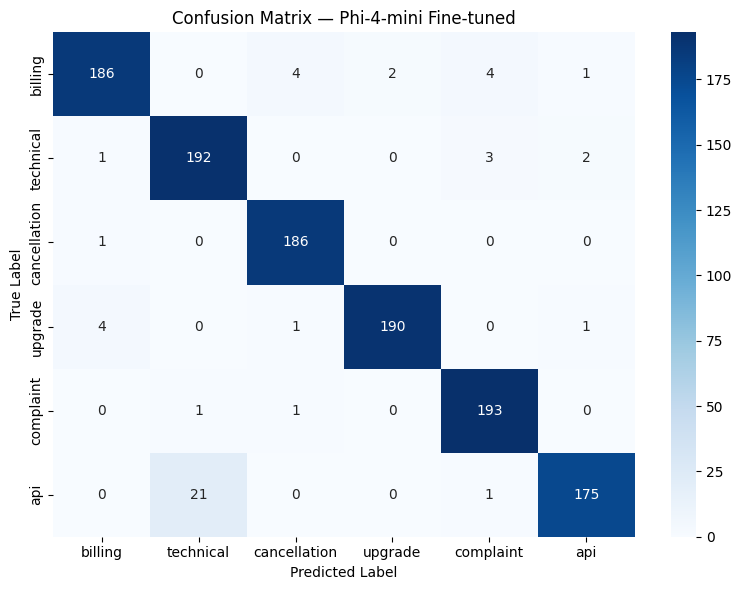

In [30]:
cm = confusion_matrix(test_df["label"], test_df["slm_pred"], labels=LABELS)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title("Confusion Matrix — Phi-4-mini Fine-tuned")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_phi-4-mini_fine-tuned.png", dpi=150)
plt.show()

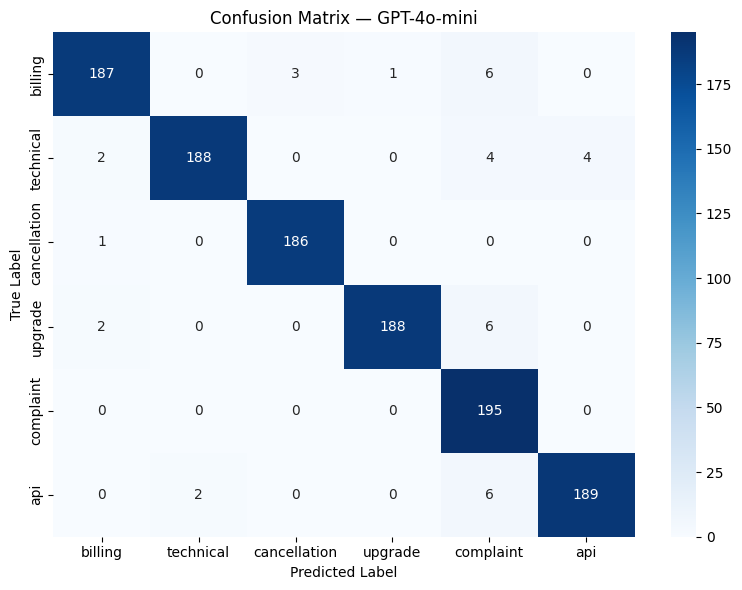

In [17]:
cm = confusion_matrix(test_df["label"], test_df["gpt_pred"], labels=LABELS)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABELS,
    yticklabels=LABELS
)
plt.title("Confusion Matrix — GPT-4o-mini")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_gpt-4o-mini.png", dpi=150)
plt.show()

In [33]:
slm_f1 = f1_score(test_df["label"], test_df["slm_pred"], average="macro")
gpt_f1    = f1_score(test_df["label"], test_df["gpt_pred"],   average="macro")

slm_avg_lat = sum(slm_latencies) / len(slm_latencies)
gpt_avg_lat   = sum(gpt_latencies) / len(gpt_latencies)

print(f"{'Metric':<30} {'SLM (Phi4 mini fine-tuned)':<30} {'GPT-4o-mini':<30}")
print(f"{'F1 Macro':<30} {slm_f1*100:<30} {gpt_f1*100:<30}")
print(f"{'Avg latency (ms)':<30} {slm_avg_lat:<30} {gpt_avg_lat:<30}")
print(f"{'Cost/call':<30} {'~$0 (local)':<30} {'$0.012 (gpt-4o-mini)':<30}")
print(f"{'Deployment':<30} {'Local (RTX 3060 6Gb)':<30} {'OpenAI API':<30}")
print("_" * 120)
print(f"Vs GPT-4o-mini : SLM is {gpt_avg_lat/slm_avg_lat:.0f}x faster")

Metric                         SLM (Phi4 mini fine-tuned)     GPT-4o-mini                   
F1 Macro                       95.91412267249568              96.87215905611298             
Avg latency (ms)               224.1847125892965              700.1365156255217             
Cost/call                      ~$0 (local)                    $0.012 (gpt-4o-mini)          
Deployment                     Local (RTX 3060 6Gb)           OpenAI API                    
________________________________________________________________________________________________________________________
Vs GPT-4o-mini : SLM is 3x faster
